--- Initializing Generalized Langevin Diffusion ---
✅ Checkpoint loaded successfully.


/var/folders/sx/y6c6vjtn04719m5bcb52hk3r0000gn/T/ipykernel_68659/1052878295.py:70: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model.load_state_dict(torch.load(chec

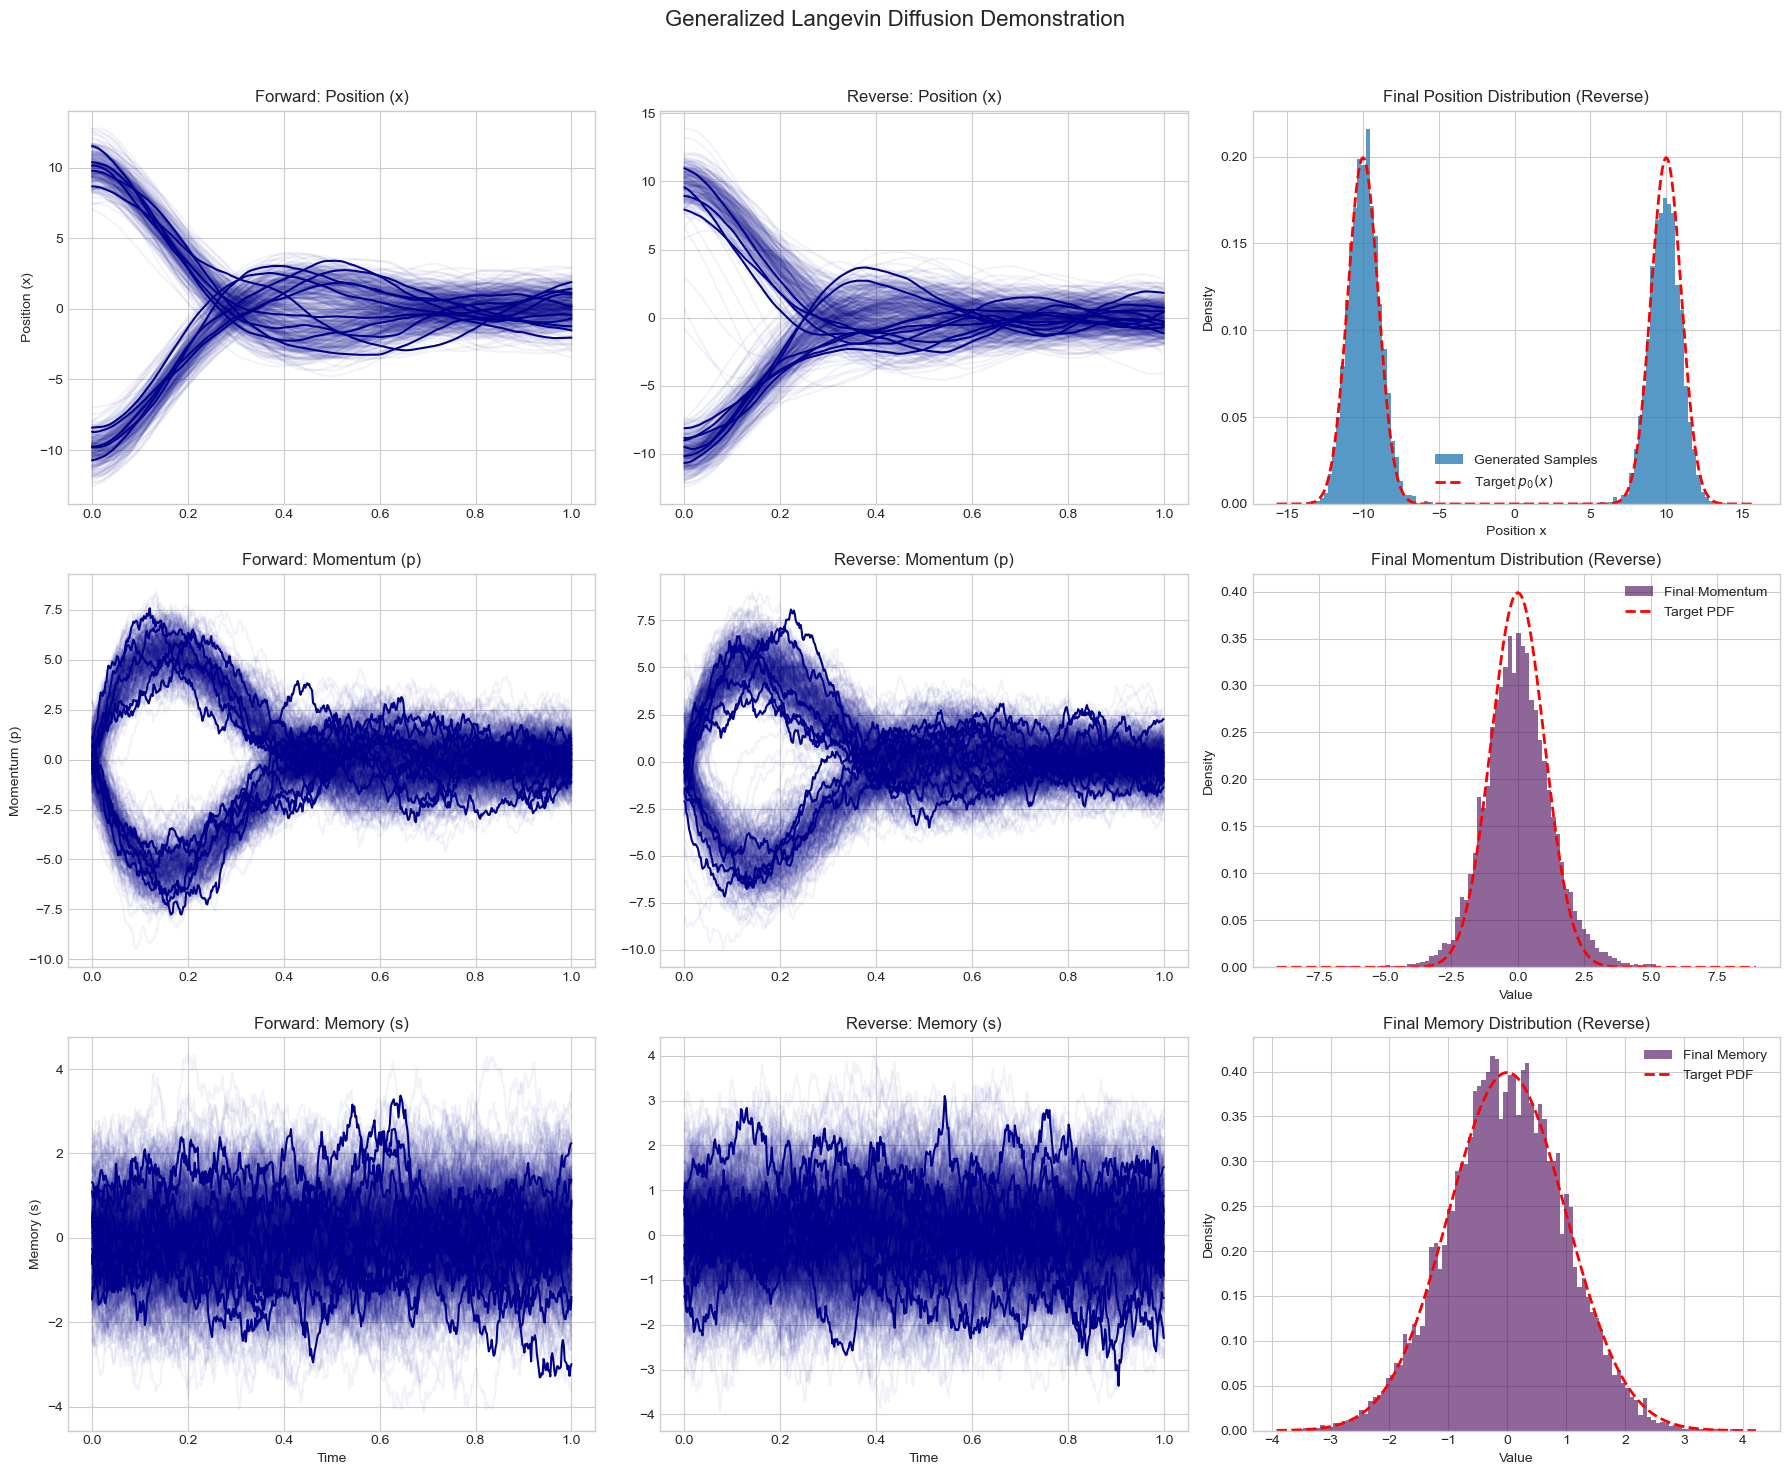

In [1]:
import os
import torch
import matplotlib.pyplot as plt
from diffusion.gld import GeneralizedLangevinDiffusion
from models import GLDScoreNetwork

# --- Define Gaussian Mixture Model (GMM) parameters ---
GMM_PARAMS = {
    "weights": [0.5, 0.5],
    "means": [-10., 10.],
    "stds": [1., 1.]
}
n_plot, n_hist = 500, 10000

cfg = {
    'n_epochs': 25,
    'batch_size': 128,
    'lr': 1e-3,
    'gmm': GMM_PARAMS,
    'gamma': 1.0,
    'lambda_val': 1.0,
    'c_val': 0.1,
    'M': 1.
}

# Build subfolder name based on config
subfolder_name = (
    f"gamma{cfg['gamma']}_lambda{cfg['lambda_val']}_"
    f"c{cfg['c_val']}_M{cfg['M']}_lr{cfg['lr']}_bs{cfg['batch_size']}"
)
save_dir = f"checkpoints/gld/{subfolder_name}"
checkpoint_path = os.path.join(save_dir, "score_net_final.pt")

# Initialize GLD
gld = GeneralizedLangevinDiffusion(
    gmm_params=cfg['gmm'],
    n_steps=500,
    inttype='em',
    gamma=cfg['gamma'],
    lambda_val=cfg['lambda_val'],
    c_val=cfg['c_val'],
    M=cfg['M']
)

train = False
if train:
    os.makedirs(save_dir, exist_ok=True)
    model, losses = gld.train_score_network_hsm(
        GLDScoreNetwork,
        n_epochs=cfg['n_epochs'],
        batch_size=cfg['batch_size'],
        lr=cfg['lr']
    )

    torch.save(model.state_dict(), checkpoint_path)

    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(losses)+1), losses, lw=2)
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title("GLD Hybrid Score Matching Loss")
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(save_dir, "training_loss.png"))
    plt.close()

    print(f"✅ Training complete. Model + loss plot saved in: {save_dir}")

# Load checkpoint
loaded_model = GLDScoreNetwork()
loaded_model.load_state_dict(torch.load(checkpoint_path))
loaded_model.eval()

print("✅ Checkpoint loaded successfully.")
#pfode_paths = gld.run_pfode_demo(n_plot, n_hist, score_model=loaded_model)
_ = gld.run_demonstration(n_plot, n_hist, score_model=loaded_model)